___
___

# Use a quantum computer today - IBM course

___
___

## Part 1 - Build and run your first quantum program

The following program builds the circuits for the four Bell states.

In [110]:
# Necessary imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [111]:
# The run function provided in the course
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

In the exercise section, the course provided a link to the Wikipedia page of [Bell states](https://en.wikipedia.org/wiki/Bell_state#Bell_basis). It shows the formulae for the 4 Bell states:

![Bell States](images/bell_states.png)


We've already created the circuit for the $\Phi$<sup>+</sup> Bell state, following is my interpretation and reasoning for the three others as well.

___

## $\Phi$<sup>+</sup> Bell state

The circuit is given in the course:
- We start with two qubits in state 0
- We apply a Hadamard gate to qubit 0 to put it into superposition
- We apply a C-NOT gate which will invert qubit 1 (to 1) only if qubit 0 is 1

The measurements collapse to 00 half the time and to 11 half the time.

![phi+](images/phi_plus.png)

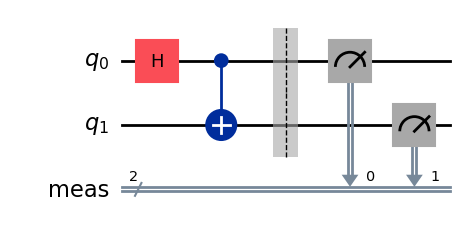

In [112]:
# The circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

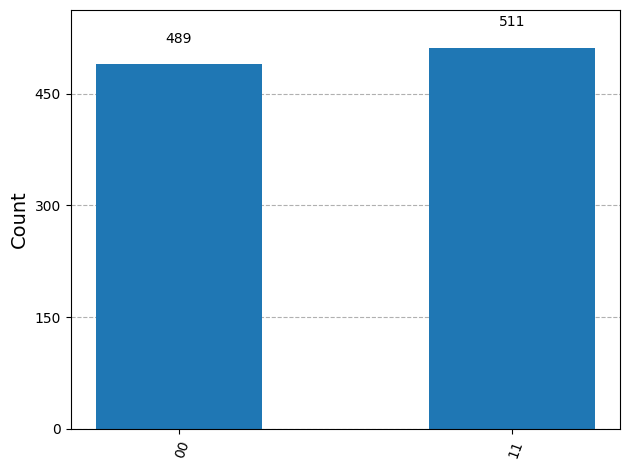

In [113]:
# The results
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend)
plot_histogram(counts)

___

## $\Psi$<sup>+</sup>  Bell state

- We start with two qubits in state 0
- We apply a Hadamard gate to qubit 0 to put it into superposition
- We apply a NOT gate to qubit 1 to set it to 1
- We apply a C-NOT gate which will invert qubit 1 (to 0) only if qubit 0 is 1

The measurements collapse to 01 half the time and to 10 half the time.

![psi+](images/psi_plus.png)

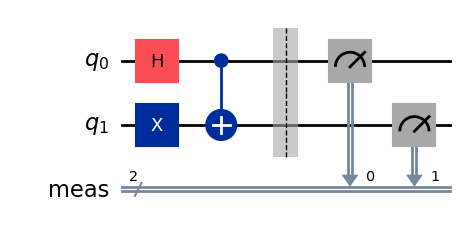

In [114]:
# The circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.x(1)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

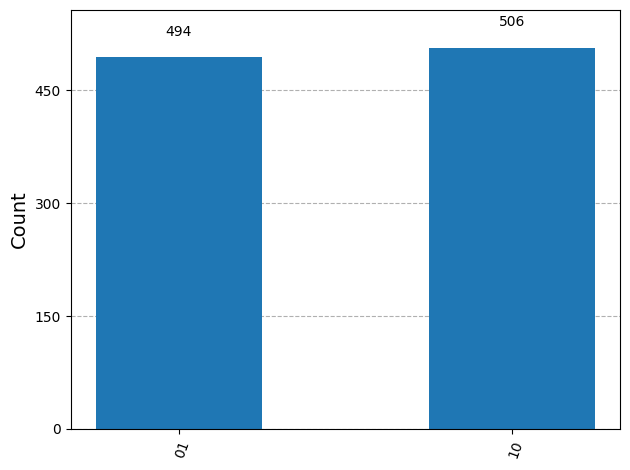

In [115]:
# The results
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend)
plot_histogram(counts)

___

For the negative states $\Phi$<sup>-</sup> and $\Psi$<sup>-</sup>, my understanding is that qubit 0 in superposition needs to be between 0 and -1 instead of 0 and 1. 

For this, a rotation needs to be applied to qubit 0 after the Hadamard gate. After looking at the [correlations between bell states](https://en.wikipedia.org/wiki/Bell_state#Bell_state_correlations) and the [possible quantum gates](https://en.wikipedia.org/wiki/Quantum_logic_gate), it seems the Z rotation is the one:

![qubit 0 rotation](images/qubit0_rotation.png)

**Notes**
- From what I understand at this point, the classical states are always either 0 or 1 in the end so qubit 0 doesn't really "collapse" to -1. The negative part accounts for the phase of the qubit, which is not represented in the classical states and which I am not yet familiar with.
- The quantum vectors use complex numbers and are represented in more than 2D so my simple representation is very incomplete. At this stage though, it seems enough to make sense of the Bell states maths. I guess it will be corrected, refined and completed as I go through the lessons.
___

## $\Phi$<sup>-</sup> Bell state

- We start with two qubits in state 0
- We apply a Hadamard gate to qubit 0 to put it into superposition
- We apply a Z gate to qubit 0 to rotate it between 0 and -1
- We apply a C-NOT gate which will invert qubit 1 (to 1) only if qubit 0 is (-)1

The measurements collapse to 00 half the time and to (-)11 half the time.

![phi-](images/phi_minus.png)

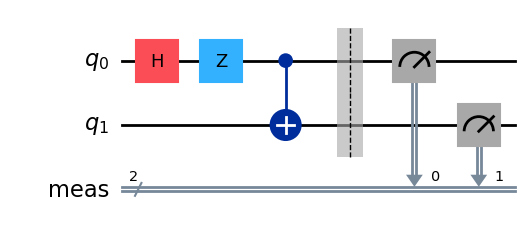

In [116]:
# The circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.z(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

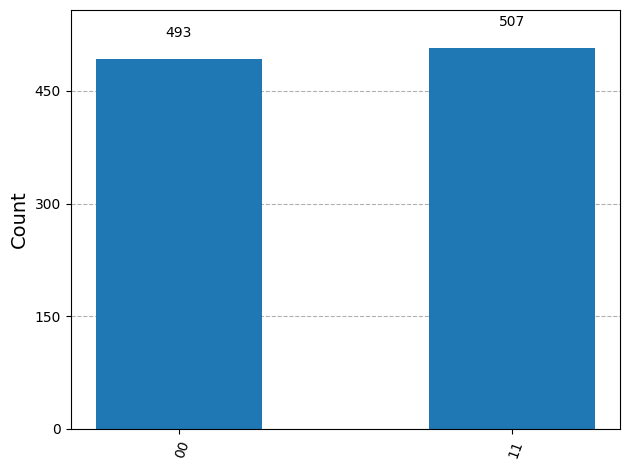

In [117]:
# The results
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend)
plot_histogram(counts)

___

## $\Psi$<sup>-</sup> Bell state

- We start with two qubits in state 0
- We apply a Hadamard gate to qubit 0 to put it into superposition
- We apply a Z gate to qubit 0 to rotate it between 0 and -1
- We apply a NOT gate to qubit 1 to set it to 1
- We apply a C-NOT gate which will invert qubit 1 (to 0) only if qubit 0 is (-)1

The measurements collapse to 01 half the time and to (-)10 half the time.

![psi-](images/psi_minus.png)

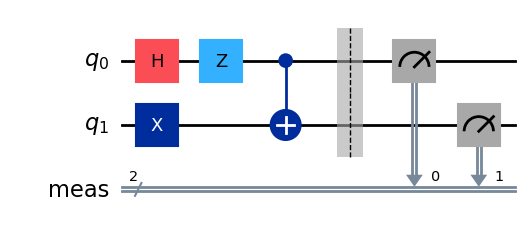

In [118]:
# The circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.z(0)
bell.x(1)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

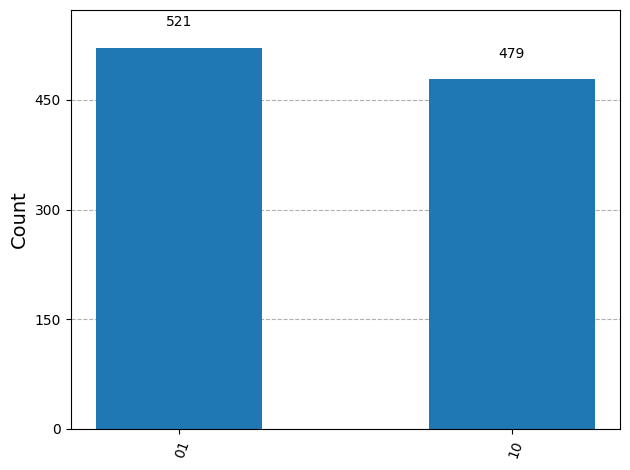

In [119]:
# The results
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend)
plot_histogram(counts)